# Use case — curating an embedding store for RAG

Before you index a knowledge base for retrieval-augmented generation, you want to **curate** it:
drop junk/off-topic documents, confirm the store really is a handful of coherent topics, and find
**topic leakage** — places where two topics blur into each other (a classic source of RAG
cross-topic confusion). `betula-cluster` does all three over the **microclusters** it already built,
in one `O(N)` pass:

- **junk** → `outlier_scores` / `find_outliers`,
- **topic coherence** → `mapper_stability` (does β₀ = #topics persist across scale?),
- **leakage** → `mapper()` **bridges** between topics.

```bash
pip install betula-cluster matplotlib seaborn pandas scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

from betula_cluster import Betula

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
rng = np.random.default_rng(1)

## A knowledge base: K topics + junk

`K` topics, each a cluster of document embeddings (10-D), plus a handful of **junk** documents far
off-distribution (scraping artefacts, boilerplate, wrong-language pages). We keep a junk flag to
score the cleanup.

In [2]:
D, K = 10, 5
centers = rng.uniform(-15, 15, (K, D))
topic_docs = [centers[t] + 0.6 * rng.standard_normal((420, D)) for t in range(K)]
n_clean = 420 * K
n_junk = 90
junk_dir = rng.standard_normal((n_junk, D))
junk = junk_dir / np.linalg.norm(junk_dir, axis=1, keepdims=True) * rng.uniform(60, 90, (n_junk, 1))

X = np.vstack([*topic_docs, junk]).astype(np.float64)
is_junk = np.r_[np.zeros(n_clean, int), np.ones(n_junk, int)]
perm = rng.permutation(len(X))
X, is_junk = X[perm], is_junk[perm]
print(f"corpus: {len(X)} documents = {n_clean} across {K} topics + {n_junk} junk")

corpus: 2190 documents = 2100 across 5 topics + 90 junk


## 1. Drop the junk — `outlier_scores`

`outlier_scores(X)` = distance to the assigned topic centroid ÷ that topic's RMS radius. Junk sits
far from every topic, so it ranks at the top; `find_outliers` returns the worst rows to cull.

In [3]:
est = Betula(n_clusters=K, feature="spherical", method="kmeans", threshold=0.0, max_leaves=300, seed=0).fit(X)
flagged = np.asarray(est.find_outliers(X, top_k=n_junk))
precision = float((is_junk[flagged] == 1).mean())
scores = np.asarray(est.outlier_scores(X))
pd.DataFrame(
    {
        "metric": [f"junk precision@{n_junk}", "median score (topic doc)", "median score (junk)"],
        "value": [f"{precision:.0%}", round(float(np.median(scores[is_junk == 0])), 2), round(float(np.median(scores[is_junk == 1])), 1)],
    }
)

,metric,value
0,junk precision@90,96%
1,median score (topic doc),0.19
2,median score (junk),4.3


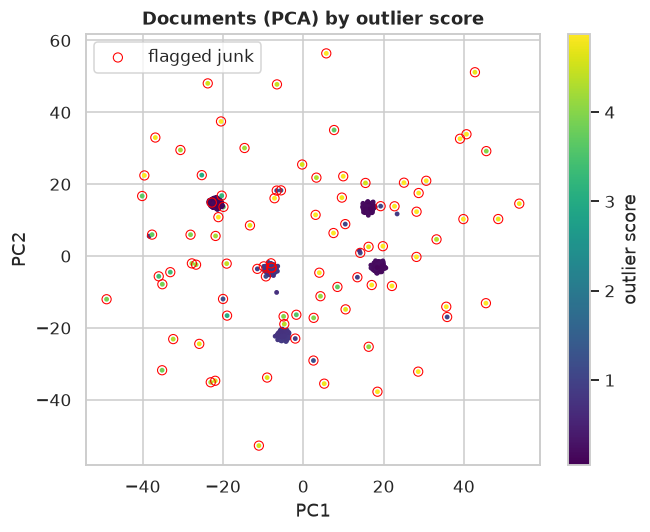

In [4]:
P = PCA(n_components=2, random_state=0).fit_transform(X)
fig, ax = plt.subplots(figsize=(6.2, 5))
sc = ax.scatter(P[:, 0], P[:, 1], c=np.clip(scores, 0, np.percentile(scores, 99)), cmap="viridis", s=10, linewidth=0)
ax.scatter(P[flagged, 0], P[flagged, 1], facecolors="none", edgecolors="red", s=36, linewidths=0.7, label="flagged junk")
ax.legend()
ax.set(title="Documents (PCA) by outlier score", xlabel="PC1", ylabel="PC2")
plt.colorbar(sc, ax=ax, label="outlier score")
plt.tight_layout()
plt.show()

## 2. Is the store really K coherent topics? — `mapper_stability`

Drop the junk, then sweep the Mapper resolution. The number of connected components **β₀** at each
scale is the number of topics the topology sees. A *persistent* flat **β₀ = K** across every
resolution is strong evidence of K clean, well-separated topics — far more robust than reading one
arbitrary Mapper graph. (The `l2norm` lens covers the store by distance-from-origin; single-linkage
inside each cover bin keeps spatially-distinct topics apart.)

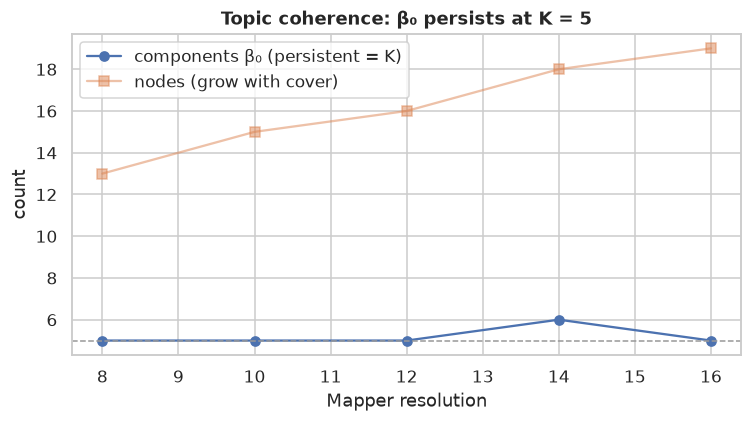

,resolution,n_nodes,n_components,n_loops
0,8,13,5,0
1,10,15,5,0
2,12,16,5,0
3,14,18,6,0
4,16,19,5,0


In [5]:
clean = X[is_junk == 0]
est_clean = Betula(n_clusters=K, feature="spherical", method="kmeans", threshold=0.0, max_leaves=300, seed=0).fit(clean)
stab = pd.DataFrame(
    est_clean.mapper_stability(resolutions=range(8, 18, 2), lens="l2norm", gain=0.3, link_scale=2.0, min_node_mass=8)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(stab["resolution"], stab["n_components"], marker="o", label="components β₀ (persistent = K)")
ax.axhline(K, color="0.6", ls="--", lw=1)
ax.plot(stab["resolution"], stab["n_nodes"], marker="s", alpha=0.5, label="nodes (grow with cover)")
ax.set(xlabel="Mapper resolution", ylabel="count", title=f"Topic coherence: β₀ persists at K = {K}")
ax.legend()
plt.tight_layout()
plt.show()
stab[["resolution", "n_nodes", "n_components", "n_loops"]]

## 3. Find topic leakage — do the topics stay separate?

The failure mode RAG cares about: two topics that **blur into each other**, so retrieval pulls the
wrong context. Mapper makes it visible. Two **well-separated** topics show up as **β₀ = 2** — two
components, stable across every resolution. Two **overlapping** topics (documents that could belong
to either) collapse to **β₀ = 1**: Mapper cannot pull them apart, and the merged region is spanned by
**bridge** edges. A persistent β₀ *below* the expected topic count is your leakage alarm.

In [6]:
def two_topics(gap, seed):
    r = np.random.default_rng(seed)
    a = r.normal([0.0, 0.0], 0.6, (700, 2))
    b = r.normal([gap, 0.0], 0.6, (700, 2))
    return np.vstack([a, b]).astype(np.float64)


separated = two_topics(gap=10.0, seed=3)  # two distinct subjects
leaking = two_topics(gap=3.0, seed=4)  # subjects that overlap → leakage
MK = dict(lens="coordinate", coordinate=0, gain=0.35, link_scale=2.5, min_node_mass=10)
m_sep = Betula(feature="spherical", method="hdbscan", threshold=0.0, max_leaves=300).fit(separated)
m_leak = Betula(feature="spherical", method="hdbscan", threshold=0.0, max_leaves=300).fit(leaking)
g_sep, g_leak = m_sep.mapper(resolution=10, **MK), m_leak.mapper(resolution=10, **MK)
b0_sep = [r["n_components"] for r in m_sep.mapper_stability(resolutions=range(8, 18, 2), **MK)]
b0_leak = [r["n_components"] for r in m_leak.mapper_stability(resolutions=range(8, 18, 2), **MK)]
pd.DataFrame(
    {
        "topic pair": ["well-separated", "overlapping"],
        "β₀ across scale": [str(b0_sep), str(b0_leak)],
        "verdict": ["two distinct topics", "topics merge (β₀ = 1) — leakage to investigate"],
    }
)

,topic pair,β₀ across scale,verdict
0,well-separated,"[2, 2, 2, 2, 2]",two distinct topics
1,overlapping,"[1, 1, 1, 1, 1]",topics merge (β₀ = 1) — leakage to investigate


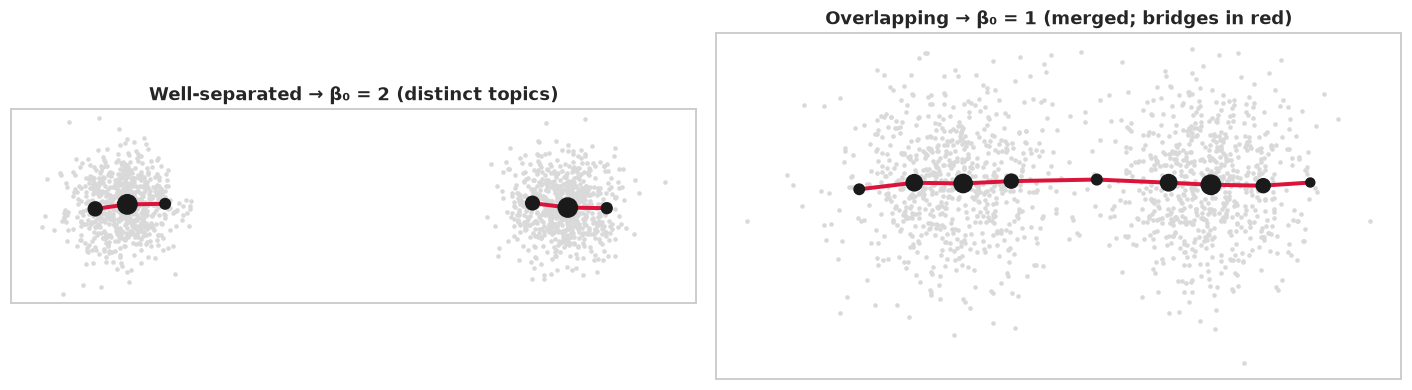

In [7]:
def plot_mapper(ax, pts, g, title):
    ax.scatter(pts[:, 0], pts[:, 1], s=4, color="0.85", zorder=1)
    pos = g.node_centroids
    bridge = set(g.bridges.tolist())
    for e, (a, b, _w) in enumerate(g.edges):
        col, lw = ("crimson", 2.6) if e in bridge else ("steelblue", 1.0)
        ax.plot([pos[a, 0], pos[b, 0]], [pos[a, 1], pos[b, 1]], color=col, lw=lw, zorder=2)
    size = 30 + 130 * g.node_mass / g.node_mass.max()
    ax.scatter(pos[:, 0], pos[:, 1], s=size, c="k", zorder=3)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
plot_mapper(axes[0], separated, g_sep, f"Well-separated → β₀ = {b0_sep[0]} (distinct topics)")
plot_mapper(axes[1], leaking, g_leak, f"Overlapping → β₀ = {b0_leak[0]} (merged; bridges in red)")
plt.tight_layout()
plt.show()

## The curation workflow

1. **`outlier_scores`** → cull junk / off-distribution pages.
2. **`mapper_stability`** → confirm the store is *K* coherent topics (persistent β₀ = K).
3. **β₀ below the expected topic count** → topic leakage: two subjects Mapper can't pull apart;
   split or relabel them so retrieval doesn't blur two topics.
4. (and **`find_near_duplicates`** to collapse reposts — see
   [`usecase_01_embedding_dedup`](usecase_01_embedding_dedup.ipynb)).

All of it runs over the `M ≪ N` microclusters the CF-tree already holds, and streams via
`partial_fit`, so it scales to a corpus far larger than RAM. For the Mapper internals see
[`05_topology_mapper`](../05_topology_mapper.ipynb).